In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.interpolate import RegularGridInterpolator

In [2]:
#cube = fits.open("alex_test.fits")[0].data
cube = fits.open("/dat/milic/muram_from_rebecca/alex_test.fits")[0].data

In [3]:
cube.shape

(8, 100, 768, 768)

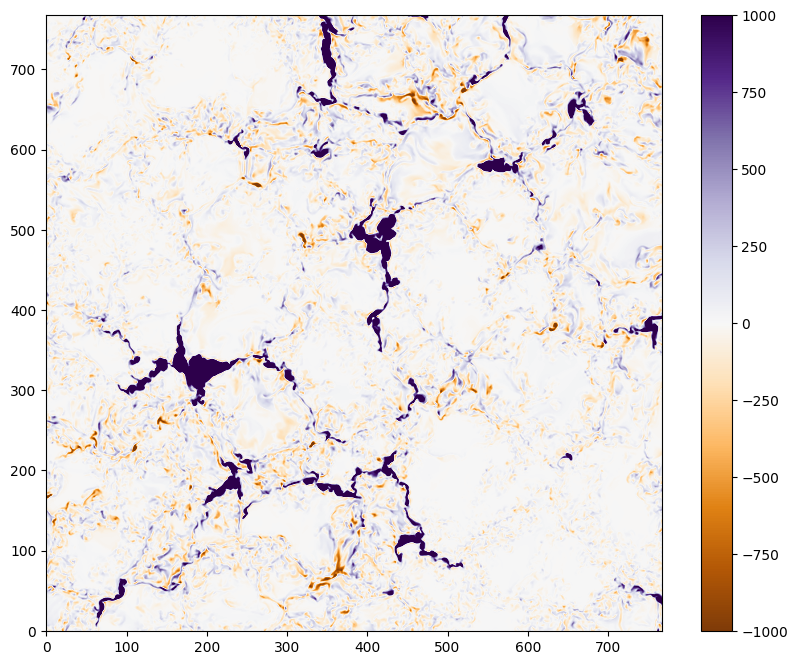

In [8]:
plt.figure(figsize=[10,8])
#plt.imshow(cube[5,64,:,:].T,origin='lower',cmap='magma')
plt.imshow(cube[7,64,:,:]*np.sqrt(4.0*np.pi).T,origin='lower',cmap='PuOr', vmin=-1000,vmax=1000)
plt.colorbar()

In [ ]:
plt.figure(figsize=[14,3])
plt.imshow(cube[0,:,:,320],origin='lower',cmap='magma', aspect='equal')
#plt.imshow(cube[7,64,:,:]*np.sqrt(4.0*np.pi).T,origin='lower',cmap='PuOr', vmin=-1000,vmax=1000)
plt.colorbar()

Interpolation proceeds one y at the time, we interpolate in the x,z axis. 

We interpolate by starting from the bottom and shifting each row by: 

$\tan \theta = \frac{dx}{dz}$

Here we know dz (16 km), so we easily calculate dx

In [5]:
theta = np.radians(65.0)
dz = 16.0 #km 

dx = dz * np.tan(theta)

print (dx)

34.31211072815294


In [6]:
cube = cube.transpose(0,2,3,1)

In [7]:
# allocate new cube

cube_titled = np.copy(cube)
cube_titled[:,:,:,:] = 0.0

In [8]:
NX, NY, NZ = cube.shape[1:]
print (NX,NY,NZ)

768 768 100


In [9]:
x = np.arange(NX) * 16.0 
y = np.arange(NY) * 16.0
z = np.arange(NZ) * 16.0

In [10]:
from scipy.interpolate import interp1d

In [ ]:
# Let's do one slice 
j = 0

cube_titled[:,:,j,-1] = cube[:,:,j,-1] 

for k in range(NZ-2,-1,-1):
    
    # Produce shifted x range
    
    x_shifted = x + k * dx
    
    # mirror 
    
    x_left = x - x[-1]
    x_right = x + x[-1]
    
    # then we need values to interpolate
    
    for p in range(0,8):
        
        y_to_interpolate = cube[p,:,j,k]
        
        x_total = np.hstack((x_left,x,x_right))
        y_total = np.hstack((y_to_interpolate,y_to_interpolate,y_to_interpolate))
        
        f = interp1d(x_total,y_total)
        
        interpolated = f(x_shifted)
        
        cube_titled[p,:,j,k] = interpolated

In [11]:
test0 = cube[0,:,0,:]
test = cube_titled[0,:,0,:]

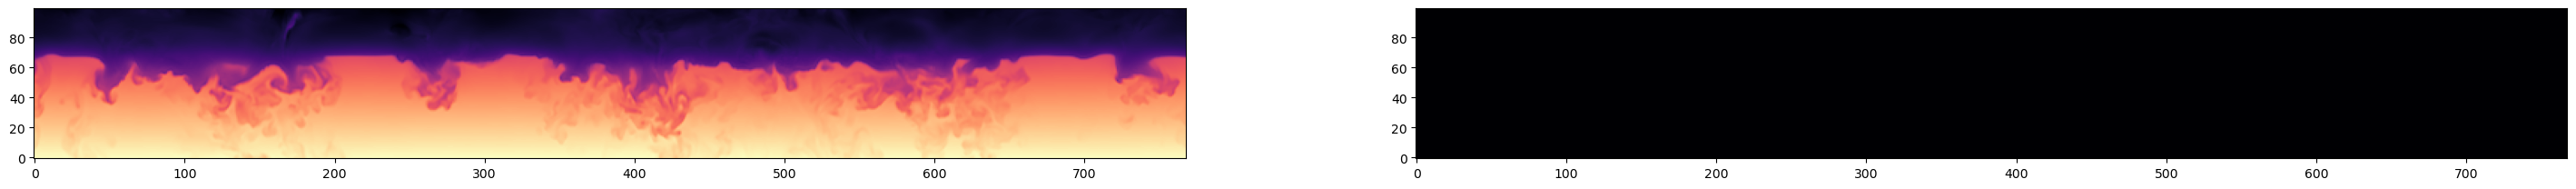

In [12]:
plt.figure(figsize=[36,18])
plt.subplot(121)
plt.imshow(test0.T,origin='lower',cmap='magma')
plt.subplot(122)
plt.imshow(test.T,origin='lower',cmap='magma')

## Now we are trying something better, according to what Juanma Borrero suggested.

In [13]:
cube.shape

(8, 768, 768, 100)

In [14]:
theta = np.radians(65)
phi = np.radians(0)

In [15]:
# Let's do one slice: 


dzt = dz * np.cos(theta)
dxt = dz * np.sin(theta) * np.cos(phi)
dyt = dz * np.sin(theta) * np.sin(phi)

zt_max = z[-1] / np.cos(theta)

NZ_new = int(zt_max // dz)

In [16]:
cube_tilted = np.zeros([8,NX,NY,NZ_new])

In [17]:
%%time 

T_interpolator = RegularGridInterpolator((x,y,z), cube[0])

CPU times: user 125 µs, sys: 56 µs, total: 181 µs
Wall time: 196 µs


In [18]:
%%time
# This is the main loop where we fill our cube:

j = 0 


for i in range(0, NX):
    
    # Create the values on the ray. We will want to start from the top:
    
    zt = z[-1] - np.arange(NZ_new) * dzt
    xt = x[i] - np.arange(NZ_new) * dxt
    yt = y[j] - np.arange(NZ_new) * dyt
    
    # we shift the axis so that everything is inside of the original domain:

    # Find minimum and maximum values of xt and see how many times we have to 'fold'
    x_t_min = np.min(xt)
    x_t_max = np.max(xt)
    
    N_fold_min = (x[0] - x_t_min) // x[-1] + 1 
    N_fold_max = (x_t_max - x[-1]) // x[-1] + 1 

    N_fold = int(np.max([N_fold_min, N_fold_max]))
    #print(N_fold_min, N_fold_max, N_fold)

    for ii in range(0,N_fold):
        x_t_smaller = np.where(xt < x[0])
        x_t_larger = np.where(xt > x[-1])

        xt[x_t_smaller] += x[-1]
        xt[x_t_larger] -= x[-1]
        
    grid = np.concatenate((xt[:,np.newaxis],yt[:,np.newaxis],zt[:,np.newaxis]),axis=1)
    cube_tilted[0,i,j,:] = T_interpolator(grid)
    

CPU times: user 150 ms, sys: 0 ns, total: 150 ms
Wall time: 150 ms


In [19]:
cube_tilted = cube_tilted[:,:,:,::-1]

In [20]:
test0 = cube[0,:,0,:]
test01 = cube_titled[0,:,0,:]
test = cube_tilted[0,:,0,:]

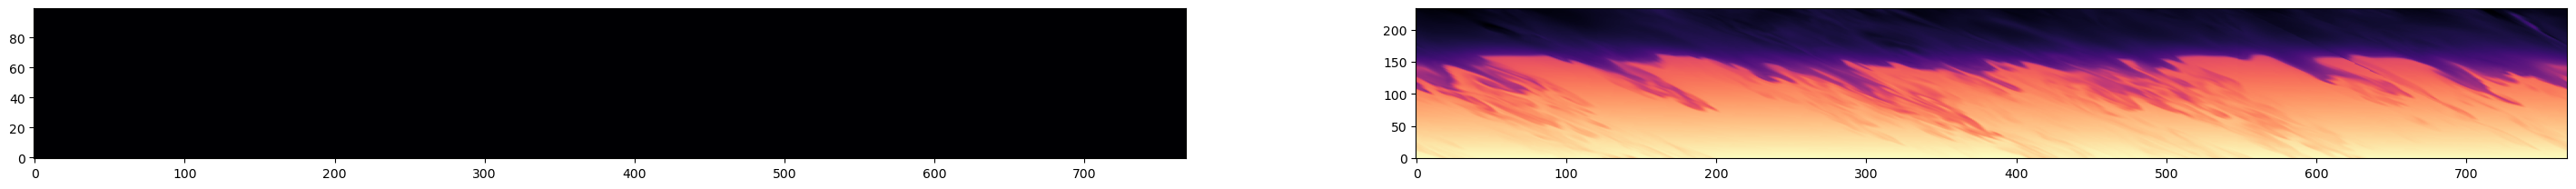

In [21]:
plt.figure(figsize=[36,18])
plt.subplot(121)
plt.imshow(test01.T,origin='lower',cmap='magma')
plt.subplot(122)
plt.imshow(np.roll(test.T,-220),origin='lower',cmap='magma',aspect=1./2.34)